## Importing the modules

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import random
import time

In [2]:
ds = glob.glob('./**.csv')

## Task 1 : Regularization

Generate total 300 values to test regularization from range[1, 150] with an interval of 0.5.

In [3]:
lambda_param = np.arange(0, 150, 0.5)

In [4]:
# Reading the csv files and extracting the features and labels into an numpy array
# Store all the features and labels into one dataset dictionary

def extract_features():
    dataset = {}
    train_features = glob.glob('./train-*.csv')
    train_labels = glob.glob('./trainR-*.csv')
    test_features = glob.glob('./test-*.csv')
    test_labels = glob.glob('./testR-*.csv')
    dataset_list = [train_features, train_labels, test_features, test_labels]
    dataset_map = {0 : 'train_features', 1 : 'train_labels', 2 : 'test_features', 3 : 'test_labels'}
    count = 0
    for dset in dataset_list:
        dataset[dataset_map.get(count)] = {}
        for dset_file in dset:
            csv_dset = pd.read_csv(dset_file, header = None)
            csv_dset = csv_dset.to_numpy()
            dset_name = dset_file.split('-')[-1].split('.')[0]
            dataset[dataset_map.get(count)][dset_name] = csv_dset
        count += 1
            
    return dataset
        
    

In [5]:
# Computation of mean squared error
mse = lambda x, y, z : (np.square(np.dot(x, y) - z)).mean()

'''
Bayesian linear regression method which calculates optimal value for W using eq.(3.28)
from Bishop's text and returns mse on train and test set.
'''
def BLR(train_data, train_labels, val_data, val_labels, reg_param):
    
    feature_product = np.dot(train_data.T, train_data)
    regularizing_matrix = reg_param * np.eye(feature_product.shape[0])
    inverse_part = np.linalg.inv(regularizing_matrix + feature_product)
    feature_label_dot = np.dot(train_data.T, train_labels)
    W = np.dot(inverse_part.T, feature_label_dot)
    mse_res_train = mse(train_data, W, train_labels)
    
    mse_res_test = mse(val_data, W, val_labels)
    return mse_res_train, mse_res_test


def Training_task1(lambda_param, dataset):
    
    mse_solution_train = {}
    mse_solution_test = {}
    
    #Iterate over all datasets
    for train_set_name in dataset['train_features']:
        
        mse_solution_train[train_set_name] = []
        mse_solution_test[train_set_name] = []
        train_set = dataset['train_features'][train_set_name]
        train_labels = dataset['train_labels'][train_set_name]
        test_set = dataset['test_features'][train_set_name]
        test_labels = dataset['test_labels'][train_set_name]
        
        #calculate mse for all regularization params
        for reg_param in lambda_param:
             
            mse_res_train, mse_res_test = BLR(train_set, train_labels, test_set,
                                              test_labels, reg_param)
            mse_solution_train[train_set_name].append(mse_res_train)
            mse_solution_test[train_set_name].append(mse_res_test)
            
    return mse_solution_train, mse_solution_test

# Plotting the mse on curve
def plot(mse_tr, mse_tst, lambda_param):
    
    fig = plt.figure(figsize = (14, 12))
    count = 1
    mode = ['mse_train', 'mse_test'] 
    for dset in mse_tr.keys():
        i = 0
        for md in mode:
            plt.subplot(2, 2, count)
            plt.title(dset)
            if i == 0:
                plt.plot(lambda_param, mse_tr[dset])
            else:
                plt.plot(lambda_param, mse_tst[dset])
                
            plt.xlabel('lambda values')
            plt.ylabel('MSE')
            plt.legend(mode)
            plt.tight_layout()
            i += 1
            
        count += 1
        
        
    
    
    
    

In [6]:
dataset = extract_features()

In [7]:
mse_tr, mse_tst = Training_task1(lambda_param, dataset)

<ipython-input-5-3f72f5adb3a4>:55: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(2, 2, count)
<ipython-input-5-3f72f5adb3a4>:55: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(2, 2, count)
<ipython-input-5-3f72f5adb3a4>:55: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be creat

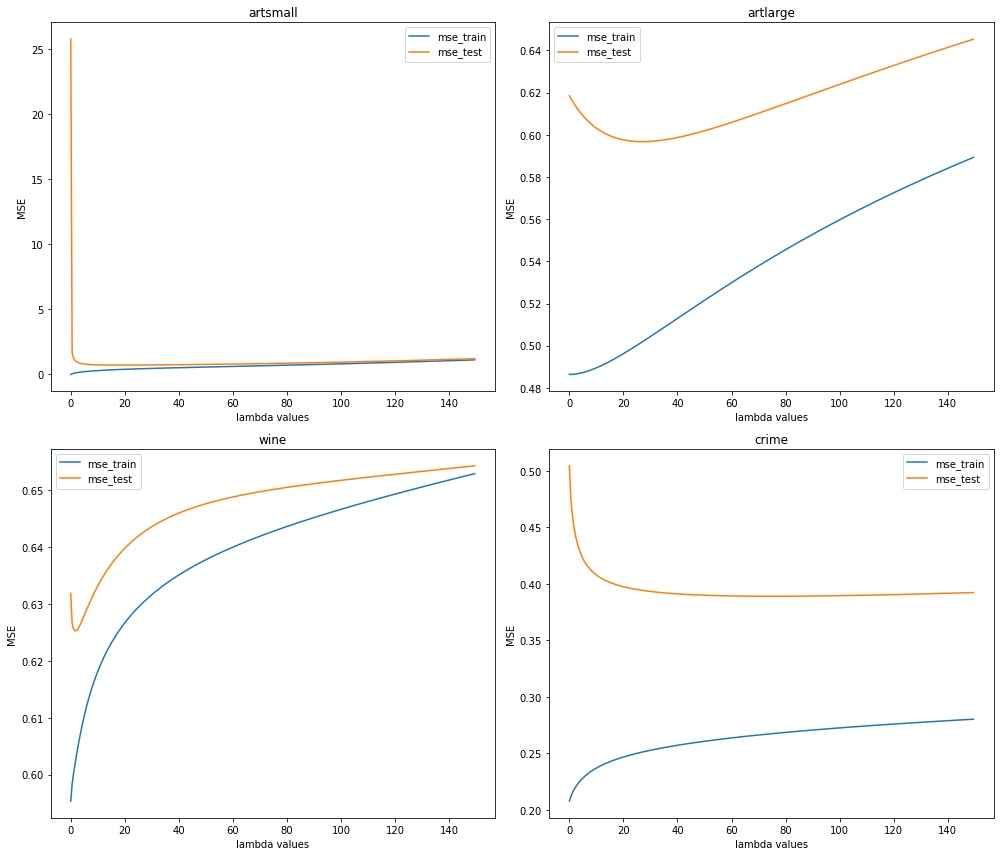

In [8]:
plot(mse_tr, mse_tst, lambda_param)

In [9]:
# Calculating the best regularization param for which we get a minimum mse
def best_lambda(output, lambda_param):
    
    best_lambda_param = {}
    for dset in output.keys():
        dset_op = np.array(output[dset])
        idx = np.argmin(dset_op, axis = 0)
        best_lambda = lambda_param[idx]
        best_lambda_param.update({dset : best_lambda})
    return best_lambda_param
        

In [10]:
best_hyper_params_tr = best_lambda(mse_tr, lambda_param)

In [11]:
best_hyper_params_tr

{'artsmall': 0.0, 'artlarge': 0.0, 'wine': 0.0, 'crime': 0.0}

In [12]:
best_hyper_params_tst = best_lambda(mse_tst, lambda_param)

In [13]:
best_hyper_params_tst

{'artsmall': 18.5, 'artlarge': 27.0, 'wine': 1.5, 'crime': 75.0}

In [14]:
for dset in dataset['train_features'].keys():
    x = mse_tst[dset]
    print(f'Minimum MSE for dataset {dset} is {min(x)}')


Minimum MSE for dataset artsmall is 0.7202668120901989
Minimum MSE for dataset artlarge is 0.5967438457327071
Minimum MSE for dataset wine is 0.6252934451881244
Minimum MSE for dataset crime is 0.38902338771344414


In [15]:
for dset in dataset['train_features'].keys():
    x = mse_tst[dset]
    print(f'MSE at value 0 for dataset {dset} is {x[0]}')

MSE at value 0 for dataset artsmall is 25.790544592550578
MSE at value 0 for dataset artlarge is 0.6184433516162854
MSE at value 0 for dataset wine is 0.6318944725472341
MSE at value 0 for dataset crime is 0.5046023504869538


## Task 2 : Model selection using Cross Validation

In [16]:
# Generating K folds from a dataset
def create_kfolds(dataset, labels, num_folds):
    
    len_dataset = dataset.shape[0]
    single_fold_len = int(len_dataset / num_folds)
    folds = {}
    for fld in range(num_folds):
        dset_fold = dataset[fld * single_fold_len : fld * single_fold_len + single_fold_len]
        labels_fold = labels[fld * single_fold_len : fld * single_fold_len + single_fold_len]
        folds[fld] = {}
        folds[fld]['dataset'] = dset_fold
        folds[fld]['labels'] = labels_fold
    return folds

In [17]:
# Below method calculates the mse on given test_fold for a particular regularization param.
def train_kfolds_iter(folds, test_fold, reg_param):
    
    dset = []
    labels = []
    for fold in folds:
        if fold != test_fold:
            dset.append(folds[fold]['dataset'])
            labels.append(folds[fold]['labels'])
            
    merged_data = np.concatenate(dset)
    merged_labels = np.concatenate(labels)
    val_data = folds[test_fold]['dataset']
    val_labels = folds[test_fold]['labels']
    
    mse_train, mse_test = BLR(merged_data, merged_labels, val_data, val_labels, reg_param)
    return mse_train, mse_test


# Training a K fold cross validation across all datasets and for all regularization params.
def training_BLR_kfold(dataset, lambda_param):
    
    num_folds = 10
    dset_names = dataset['train_features'].keys()
    mse_res = {}
    for dset in dset_names:
        if dset not in dataset:
            mse_res[dset] = []
        folds = create_kfolds(dataset['train_features'][dset], dataset['train_labels'][dset], num_folds)
        for reg_param in lambda_param:
            dset_output = []
            for fold in range(num_folds):
                _, mse_test = train_kfolds_iter(folds, fold, reg_param)
                dset_output.append(mse_test)
                
            mse_res[dset].append(sum(dset_output) / len(dset_output))
            
    return mse_res

In [18]:
output = training_BLR_kfold(dataset, lambda_param)

In [19]:
# Plotting of average MSE across all datasets using k fold validation
def plot_kfold(output):
    
    fig = plt.figure(figsize = (14, 12))
    count = 1
    for dset in output.keys():
        plt.subplot(2, 2, count)
        plt.title(dset)
        plt.plot(lambda_param, output[dset])
        plt.xlabel('lambda values')
        plt.ylabel('MSE')
        plt.tight_layout()
        count += 1
            

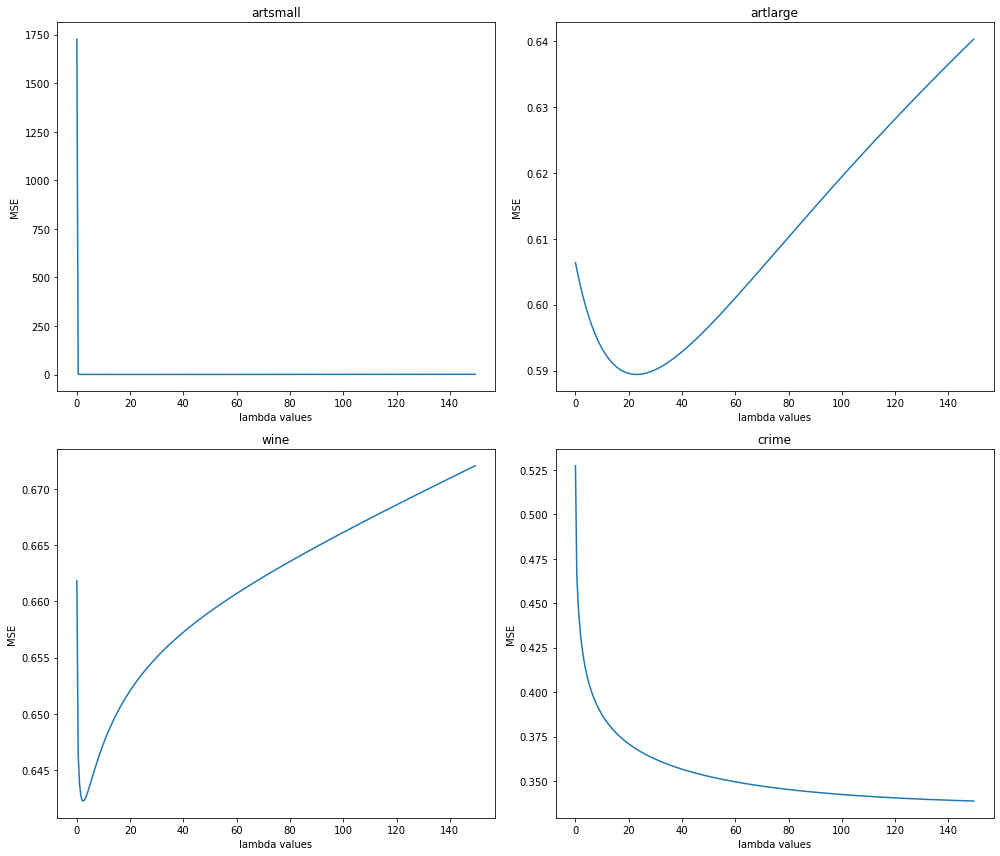

In [20]:
plot_kfold(output)

In [21]:
best_hyper_params = best_lambda(output, lambda_param)

In [22]:
best_hyper_params

{'artsmall': 17.5, 'artlarge': 23.0, 'wine': 2.5, 'crime': 149.5}

In [23]:
'''
Below method implements the k fold validation training for all datasets and 
after calculating the best hyper parameter for regularization it will retrain
the BLR model.
'''
def retrain_mse(dataset, lambda_param):
    
    # First do the k fold training for BLR for all datasets and find the best \
    # regularization param.
    mse_optimal = []
    time_kfold = time.time()
    mse_res = training_BLR_kfold(dataset, lambda_param)
    best_hyper_params = best_lambda(mse_res, lambda_param)
    time_kfold_total = time.time() - time_kfold
    
    time_retraining = time.time()
    
    # Retraining of all datasets with optimal regularization that found in previous step.
    for dset in dataset['train_features'].keys():
        
        train_features = dataset['train_features'][dset]
        train_labels = dataset['train_labels'][dset]
        test_features = dataset['test_features'][dset]
        test_labels = dataset['test_labels'][dset]
        lambda_optimal = best_hyper_params[dset]
        _, mse_test = BLR(train_features, train_labels, test_features, test_labels, lambda_optimal)
        mse_optimal.append([dset, mse_test])
        
    time_retraining_total = time.time() - time_retraining
    return mse_optimal, time_kfold_total, time_retraining_total
        
        
    

In [24]:
res, time_kfold_total, time_retraining_total = retrain_mse(dataset, lambda_param)

In [25]:
res

[['artsmall', 0.7203551952121033],
 ['artlarge', 0.5970023803034378],
 ['wine', 0.6255518654110065],
 ['crime', 0.39230465512684803]]

In [26]:
time_kfold_total

6.369485855102539

In [27]:
time_retraining_total

0.00225067138671875

## Task 3 : Bayesian Model Selection

In [28]:
# Calculate posterior parameters Mn and Sn for BLR model.
def calculate_posterior(alpha, beta, features, labels):
    
    feature_dot =  np.dot(features.T, features)
    Identity_matrix = np.eye(feature_dot.shape[0])
    Sn_inverse = alpha * Identity_matrix + beta * feature_dot
    Sn = np.linalg.inv(Sn_inverse)
    Mn = beta * np.dot(Sn, np.dot(features.T, labels))
    return Mn, Sn

# Model selection method that iterate over until the algorithm converges
def Model_Selection(features, labels):
      
    alpha, beta = random.sample(range(1, 10), 2)
    i = 0
    while True:
        Mn, Sn = calculate_posterior(alpha, beta, features, labels)
        eig_values = beta * np.linalg.eigvalsh(np.dot(features.T, features))
        gamma = np.sum(eig_values / (eig_values + alpha))
        alpha_updated = gamma / np.sum(np.dot(Mn.T, Mn))
        square_error = np.sum(np.square(labels - np.dot(features, Mn)))
        beta_inverse = (1 / (features.shape[0] - gamma)) * square_error
        beta_updated = 1 / beta_inverse
        
        # Check if the algorithm converge or not
        if (abs(alpha_updated - alpha) < 0.0001) and (abs(beta_updated - beta) < 0.0001):
            print(f'Model converged at iteration : {i}')
            gamma = alpha_updated / beta_updated
            return alpha_updated, beta_updated, gamma
        else:
            alpha = alpha_updated
            beta = beta_updated
            
        i += 1
            
        
        
        
    
    

In [29]:
def train_model(dataset):
    
    results = []
    for dset in dataset['train_features'].keys(): 
        start = time.time()
        train_features = dataset['train_features'][dset]
        train_labels = dataset['train_labels'][dset]
        test_features = dataset['test_features'][dset]
        test_labels = dataset['test_labels'][dset]
        alpha, beta, gamma = Model_Selection(train_features, train_labels)
        _, mse_test = BLR(train_features, train_labels, test_features, test_labels, gamma)
        time_taken = time.time() - start
        results.append([dset, alpha, beta, gamma, mse_test, time_taken ])
        
    return results

        

In [30]:
results = train_model(dataset)

Model converged at iteration : 11
Model converged at iteration : 4
Model converged at iteration : 18
Model converged at iteration : 15


In [31]:
results

[['artsmall',
  5.15460578297627,
  3.1543341313810846,
  1.6341343587210249,
  1.0635158788188126,
  0.017623186111450195],
 ['artlarge',
  10.285792718713893,
  1.8603093622427112,
  5.52907646839651,
  0.608308592067237,
  0.011878490447998047],
 ['wine',
  6.1638825357111084,
  1.609809286726426,
  3.8289520296192765,
  0.6267461737285874,
  0.006087541580200195],
 ['crime',
  425.64535342687367,
  3.2504320750788693,
  130.95039170032362,
  0.391102307257833,
  0.02577829360961914]]